# 基于随机微分方程（SDE）的得分生成模型

在之前的扩散模型教程（DDPM、SMLD）中，我们已经看到如何通过**逐步反转数据加噪过程**来生成干净的图像。  
在本教程中，我们将通过**随机微分方程（Stochastic Differential Equations, SDE）**的视角来理解（解释）这些方法。

通过揭示**离散迭代过程与随机微分方程（SDE）之间的联系**，我们能够从**统一的理论视角**理解 DDPM 与 SMLD 这两种不同的方法，并进一步利用连续 SDE 的视角改进模型训练过程和图像生成过程。

## 架构与方法

让我们简要地遵循原始论文 [[Song, et. al., 2021](https://arxiv.org/pdf/2011.13456)]，了解基于随机微分方程（SDE）的得分生成模型背后的理论知识。

### 1. 随机微分方程（SDE）的视角解释

到目前为止，我们已经学习了两种扩散模型的变体 —— **DDPM** 和 **SMLD**。  
在这两种算法中，扩散过程都是以**离散形式**进行有限次迭代操作。

众所周知，许多离散时间算法都可以对应到某种**连续形式的微分方程**。  
例如，回顾用于寻找最小值的梯度下降算法，其离散形式的迭代过程，在极限情况下满足某个连续空间中的微分方程。

普通微分方程可以通过积分求解。  
例如，微分方程
$$
\frac{d\mathbf{x}(t)}{dt}=f(\mathbf{x}(t), t)
$$
的解为：
$$
\displaystyle \mathbf{x}(t) = \mathbf{x}(0) + \int_0^t f(\mathbf{x}(s), s) ds
$$

与普通微分方程类似，**随机微分方程（Stochastic Differential Equation, SDE）** 是在微分方程中加入随机过程项（如白噪声）的形式。  
根据相关论文，扩散过程可以被建模为如下连续形式的随机微分方程：

$$
\displaystyle \frac{d\mathbf{x}(t)}{dt} = f(\mathbf{x}(t), t) + g(t) \xi(t)
$$

其中 $\xi(t) \sim \mathcal{N}(\mathbf{0},\mathbf{I})$。

在该方程中，$f(\mathbf{x}(t), t)$ 是称为 **漂移项（drift）** 的向量函数，$g(t)$ 是称为 **扩散系数（diffusion coefficient）** 的标量函数。

该方程也常被记为：

$$
\displaystyle d\mathbf{x} = f(\mathbf{x}, t)dt + g(t) d \mathbf{w} \;\;\;\;\;\; (1)
$$

其中 $d \mathbf{w} = \xi(t) dt$ 为 **维纳过程（Wiener process，即布朗运动）**。

与普通微分方程类似，随机微分方程也可通过积分形式表示其解：

$$
\displaystyle \mathbf{x}(t) = \mathbf{x}(0) + \int_0^t f(\mathbf{x}(s), s) ds + \int_0^t g(s) d \mathbf{w}
$$

其中 $\int \cdot d \mathbf{w}$ 为 **Ito 积分**，其结果本身仍是一个随机过程，因此解 $\mathbf{x}(t)$ 也是随机的。

与普通微分方程的离散迭代类似，随机过程的离散迭代也可以由连续形式的随机微分方程刻画。  
根据 [[Brian Anderson, 1982](https://www.sciencedirect.com/science/article/pii/0304414982900515)]，当正向扩散过程由式 (1) 表示时，其**反向过程**满足：

$$
\displaystyle d\mathbf{x} = \left[f(\mathbf{x}, t) - g(t)^2 \nabla_{\mathbf{x}} \log p_t(\mathbf{x})\right]dt + g(t)d\bar{\mathbf{w}} \;\;\;\;\;\; (2)
$$

其中 $\bar{\mathbf{w}}$ 表示时间从 $T$ 向 $0$ 反向流动时对应的维纳过程。

可以看到，反向过程中的漂移项变为
$$
\left[f(\mathbf{x}, t) - g(t)^2 \nabla_{\mathbf{x}} \log p_t(\mathbf{x})\right],
$$
而扩散系数仍保持为相同的标量函数 $g(t)$。

![Overview of score-based generative modeling through SDEs](./assets/sde_process.png)

*引自：["Score-based Generative Modeling Through Stochastic Differential Equations"](https://arxiv.org/pdf/2011.13456)*

正如我们在 SMLD 教程中所见，$\nabla_{\mathbf{x}} \log p_t(\mathbf{x})$ 可以用神经网络表示的得分函数 $\mathbf{s}_{\theta}(\mathbf{x}, t)$ 进行近似，从而在离散形式下构造出反向迭代过程。  
因此，一旦获得扩散正向过程的随机微分方程表示，我们既可以在**连续形式**下解析地得到反向过程，也可以在**离散形式**下数值地构造该反向过程。

在本教程中，我们将实现连续形式的目标函数。


### 2. DDPM 中的随机微分方程（SDE）

在本 Notebook 中，我们将以 DDPM（Denoising Diffusion Probabilistic Models）为例进行说明。

首先，回顾 DDPM 的前向迭代过程如下（参见前一节 [DDPM 教程](./02-ddpm-cn.ipynb)）：

$$
\mathbf{x}_i = \sqrt{1-\beta_i} \mathbf{x}_{i-1} + \sqrt{\beta_i} \mathbf{z}_{i-1} \;\; (i=1,\ldots,N) \;\;\;\;\;\; (3)
$$

其中 $\beta_i = 1-\alpha_i$，且 $\mathbf{z}_{i-1} \sim \mathcal{N}(\mathbf{0},\mathbf{I})$。

在此我们引入一个关于噪声尺度的辅助连续函数 $\beta(t)$，定义为：

$$
\beta_i = \beta(t+\Delta t)\Delta t
$$

该函数 $\beta(t)$ 在直观上是如下所示的一条连续曲线（下图中假设 $\beta_i$ 线性变化）。  
在该定义中，令 $t \in \{ 0,\frac{1}{N},\ldots,\frac{N-1}{N} \}$（即 $t \in [0,1]$），并且 $\beta_i=\frac{1}{N}\beta(\frac{i}{N})$。  
当 $N \to \infty$ 时，有 $\beta(t+\Delta t)\Delta t \to 0$。

![DDPM beta function in SDE](./assets/ddpm_beta_in_sde.png)

利用该函数，我们可以将公式 (3) 改写为：

$$
\mathbf{x}(t+\Delta t) = \sqrt{1-\beta(t+\Delta t)\Delta t} \cdot \mathbf{x}(t) + \sqrt{\beta(t+\Delta t)\Delta t} \cdot \mathbf{z}(t)
$$

对 $\gamma=0$ 进行一阶线性近似，有 $\sqrt{1-\gamma} \approx 1-\frac{1}{2}\gamma$，因此得到：

$$
\mathbf{x}(t+\Delta t)
$$

$$
\approx \mathbf{x}(t) - \frac{1}{2} \beta(t+\Delta t)\Delta t \cdot \mathbf{x}(t) + \sqrt{\beta(t+\Delta t)\Delta t} \cdot \mathbf{z}(t)
$$

$$
\approx \mathbf{x}(t) - \frac{1}{2} \beta(t+\Delta t)\Delta t \cdot \mathbf{x}(t) + \sqrt{\beta(t)\Delta t} \cdot \mathbf{z}(t)
$$

因此，当 $\Delta t \to 0$ 时，有：

$$
d\mathbf{x} = -\frac{1}{2}\beta(t)\mathbf{x}dt + \sqrt{\beta(t)}d\mathbf{w} \;\;\;\;\;\; (4)
$$

> ##### 补充推导说明（从离散形式到随机微分方程）
>
> 将上述等式改写为增量形式：
>
> $
 \mathbf{x}(t+\Delta t) - \mathbf{x}(t)
 = - \frac{1}{2}\beta(t+\Delta t)\mathbf{x}(t)\Delta t
 + \sqrt{\beta(t)\Delta t} \cdot \mathbf{z}(t)
 $
>
> 当 $\Delta t \to 0$ 时，
>
> - 确定性部分满足：
$
-\frac{1}{2}\beta(t+\Delta t)\mathbf{x}(t)\Delta t
\to -\frac{1}{2}\beta(t)\mathbf{x}(t)\, dt
$
>
> - 随机项中，$\mathbf{z}(t)\sim \mathcal{N}(\mathbf{0},\mathbf{I})$，因此
$
\sqrt{\Delta t}\,\mathbf{z}(t) \;\overset{d}{=}\; d\mathbf{w},
$
>其中 $d\mathbf{w}$ 为 Wiener 过程增量，满足
$
d\mathbf{w} \sim \mathcal{N}(\mathbf{0}, \Delta t).
$
>
>于是整个离散随机过程在极限意义下收敛为以下随机微分方程（SDE）：
$$
d\mathbf{x}
= -\frac{1}{2}\beta(t)\mathbf{x}dt
+ \sqrt{\beta(t)}d\mathbf{w}
\qquad (4)
$$
>

在 DDPM 中，项 $-\frac{1}{2}\beta(t)\mathbf{x}$ 是前向过程中的**漂移项（drift coefficient）**，而 $\sqrt{\beta(t)}$ 是前向过程中的**扩散项（diffusion coefficient）**。

将该结果代入公式 (2)，即可得到反向过程的随机微分方程：

$$
d\mathbf{x}=-\beta(t)\left[\frac{1}{2}\mathbf{x} + \nabla_{\mathbf{x}} \log p_t(\mathbf{x})\right]dt + \sqrt{\beta(t)}d\bar{\mathbf{w}}
$$

再将 $\nabla_{\mathbf{x}} \log p_t(\mathbf{x})$ 替换为得分函数（神经网络）$\mathbf{s}_{\theta}(\mathbf{x}, t)$，得到：

$$
d\mathbf{x}=-\beta(t)\left[\frac{1}{2}\mathbf{x} + \mathbf{s}_{\theta}(\mathbf{x},t)\right]dt + \sqrt{\beta(t)}d\bar{\mathbf{w}} \;\;\;\;\;\; (5)
$$

这里不再展开更多细节，我们简要从 SDE 角度看一下 SMLD。  
在 SMLD 中，并没有显式的前向扩散步骤，但回顾其训练过程：输入中加入了噪声 $\mathcal{N}(\mathbf{0},\sigma^2 \mathbf{I})$。  
这意味着在 SMLD 中，每个噪声尺度的扰动对应如下马尔可夫链：

$$
\mathbf{x}_i = \mathbf{x}_{i-1} + \sqrt{\sigma_i^2 - \sigma_{i-1}^2} \mathbf{z}_{i-1}
$$

该迭代过程可写成如下随机微分方程，并同样可以推导其反向过程（结果与之前的 [SMLD 教程](./03-smld-cn.ipynb) 相同）：

$$
d\mathbf{x} = \sqrt{\frac{d[\sigma^2(t)]}{dt}}d\mathbf{w}
$$

当 $t \to \infty$ 时，该过程的方差不断增大，因此被称为 **Variance Exploding (VE) SDE**。  
相比之下，公式 (4) 则被称为 **Variance Preserving (VP) SDE**。

更多细节可参见论文 [[Song, et. al., 2021](https://arxiv.org/pdf/2011.13456)] 的附录 B。

> **注**：然而，[[Kawar et. al., 2022](https://arxiv.org/pdf/2201.11793)] 指出 VE SDE 与 VP SDE 在推断过程上是等价的（实际效果主要由所使用的模型决定）。

### 3. SDE 中的训练（连续目标）

有了上述线性 $\beta(t)$ 函数，我们现在定义：

$\displaystyle \bar{\beta}_{\min} = \min_{i \in \{0,1,\ldots,N-1\}} \beta(\frac{i}{N})$

$\displaystyle \bar{\beta}_{\max} = \max_{i \in \{0,1,\ldots,N-1\}} \beta(\frac{i}{N})$

（这里我们依旧假设 $t \in \{ 0,\frac{1}{N},\ldots,\frac{N-1}{N} \}$ (即 $t \in [0,1]$)。）

有了这个定义，我们可以将公式 (4) 重写为：

$\displaystyle d\mathbf{x} = -\frac{1}{2}(\bar{\beta}_{\min} + t(\bar{\beta}_{\max} - \bar{\beta}_{\min}))\mathbf{x}dt + \sqrt{\bar{\beta}_{\min} + t(\bar{\beta}_{\max} - \bar{\beta}_{\min})}d\mathbf{w}$

通过应用 [[Hannes Risken, 1989](https://link.springer.com/book/10.1007/978-3-642-61544-3)] 中的方程，您可以得到以下解。（请参阅以下注释。）:

$\displaystyle \mathbf{x}(t)=e^{-\frac{1}{4}t^2(\bar{\beta}_{\max} - \bar{\beta}_{\min})-\frac{1}{2}t\bar{\beta}_{\min}} \mathbf{x}(0) + \left(1 - e^{-\frac{1}{2}t^2(\bar{\beta}_{\max} - \bar{\beta}_{\min})-t\bar{\beta}_{\min}}\right) \xi(t)$

其中 $\xi(t) \sim \mathcal{N}(\mathbf{0},\mathbf{I})$。

由此可以推理出扰动核：

$p(\mathbf{x}(t)|\mathbf{x}(0)) = \mathcal{N}\left(\mathbf{x}(t) | e^{-\frac{1}{4}t^2(\bar{\beta}_{\max} - \bar{\beta}_{\min})-\frac{1}{2}t\bar{\beta}_{\min}} \mathbf{x}(0), \left(1 - e^{-\frac{1}{2}t^2(\bar{\beta}_{\max} - \bar{\beta}_{\min})-t\bar{\beta}_{\min}}\right) \mathbf{I}\right) \;\;\;\;\;\; (6)$

> 注：假设给出了随机微分方程 $\frac{d\mathbf{x}}{dt} = -a \mathbf{x} + b \xi(t) $。根据 [[Hannes Risken, 1989](https://link.springer.com/book/10.1007/978-3-642-61544-3)] 中的方程 (3.7)，方程的解为 $\mathbf{x}(t) = \mathbf{x}(0) e^{-at} + b \int_0^t e^{-a(t-s)} \xi(s) ds$。

--- 

我们的训练目标是学习任意时刻 $t$ 下边缘分布
$$
p_t(\mathbf{x}) = \int p(\mathbf{x}(t)\mid\mathbf{x}(0))\,p_0(\mathbf{x}(0))\,d\mathbf{x}(0)
$$
对应的梯度函数
$\nabla_{\mathbf{x}} \log p_t(\mathbf{x})$。
然而该边缘分布通常是不可计算的，因此直接进行 score matching 是不可行的。

破局的关键在于，边缘分布的梯度函数可以表示为条件梯度函数的期望：
$$
\nabla_{\mathbf{x}} \log p_t(\mathbf{x})
=
\mathbb{E}_{\mathbf{x}(0)\mid \mathbf{x}(t)}
\!\left[
\nabla_{\mathbf{x}} \log p(\mathbf{x}(t)\mid \mathbf{x}(0))
\right].
$$

由于公式 (6) 中的扰动核 $p(\mathbf{x}(t)\mid \mathbf{x}(0))$ 为高斯分布，其对 $\mathbf{x}(t)$ 的梯度函数具有解析解：
$$
\nabla_{\mathbf{x}(t)} \log p(\mathbf{x}(t)\mid \mathbf{x}(0))
=
-\frac{\mathbf{x}(t) - \mu(t)\mathbf{x}(0)}{\sigma^2(t)},
$$
其中
$$
\mu(t) = e^{-\frac{1}{4}t^2(\bar{\beta}_{\max} - \bar{\beta}_{\min})-\frac{1}{2}t\bar{\beta}_{\min}}, 
\qquad
\sigma^2(t) = 1 - e^{-\frac{1}{2}t^2(\bar{\beta}_{\max} - \bar{\beta}_{\min})-t\bar{\beta}_{\min}}.
$$

在实际训练过程中，我们首先从数据分布中采样 $\mathbf{x}(0)\sim p_0(\mathbf{x})$，随后根据扰动核
$p(\mathbf{x}(t)\mid\mathbf{x}(0))$ 构造加噪样本：
$$
\tilde{\mathbf{x}}
=
\mu(t)\mathbf{x}(0) + \sigma(t)\mathbf{z},
\qquad
\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I}).
$$

代入上式可得：
$$
\nabla_{\tilde{\mathbf{x}}} \log p(\tilde{\mathbf{x}}\mid \mathbf{x}(0))
=
-\frac{\mathbf{z}}{\sigma(t)}.
$$

由此，原本以 $\nabla_{\mathbf{x}} \log p_t(\mathbf{x})$ 为回归目标的 score matching 问题，
在期望意义下等价于回归上述**条件梯度函数**。因此，可以通过最小化
$$
\mathbb{E}
\left[
\left\|
\mathbf{s}_{\theta}(\tilde{\mathbf{x}}, t)
-
\nabla_{\tilde{\mathbf{x}}} \log p(\tilde{\mathbf{x}}\mid \mathbf{x}(0))
\right\|^2
\right]
=
\mathbb{E}
\left[
\left\|
\mathbf{s}_{\theta}(\tilde{\mathbf{x}}, t)
+
\frac{\mathbf{z}}{\sigma(t)}
\right\|^2
\right]
$$
来学习模型参数。

正如我们在 [SMLD 教程](./03-smld-cn.ipynb) 中所见，当假设 $\mathbf{s}_{\theta}(\mathbf{x}, t) = \nabla_{\mathbf{x}} \log p_t(\mathbf{x})$ 时，我们可以如下优化参数 $\theta$。

$\displaystyle \theta^{\ast} = \arg \min_{\theta} \left\{ \lambda(t) \mathbb{E}\left[ \left\|\mathbf{s}_{\theta}(\tilde{\mathbf{x}}, t) + \frac{\mathbf{z}}{\sigma(t)} \right\|^2 \right] \right\}$

其中 $\lambda(t)$ 是用于平衡不同时间尺度和噪声强度的加权函数，$\sigma(t)$ 是在 $t$ 时的标准差。

Score Matching 损失函数中的权重 $\lambda(t)$ 由训练策略所决定，具体取值可参考论文《[Maximum Likelihood Training of Score-Based Diffusion Models](https://arxiv.org/pdf/2101.09258)》中的 Table 1。  

在本教程中，我们在训练时采用如下形式的 $\lambda(t)$ 作为损失权重：

$$
\displaystyle \lambda(t) = 1 - e^{-\frac{1}{2}t^2(\bar{\beta}_{\max} - \bar{\beta}_{\min})-t\bar{\beta}_{\min}} = \sigma(t)^2
$$

因此，可以得到如下最优参数：

$$
\displaystyle \theta^{\ast} = \arg \min_{\theta} \left\{ \mathbb{E}\left[ \left\|\sigma(t)\mathbf{s}_{\theta}(\tilde{\mathbf{x}}, t) + \mathbf{z} \right\|^2 \right] \right\} \;\;\;\;\;\; (7)
$$

更多细节可参见论文 [[Song, et. al., 2021](https://arxiv.org/pdf/2011.13456)] 的 Appendix C。


我这样做整合可以吗，有哪些逻辑错误或者推理错误吗

### 4. SDE 中的推理过程

现在我们来考虑基于 SDE 的推理（图像生成）过程。

在推理（预测）阶段，可以采用多种采样策略。  
下面将介绍其中几种典型方法。

**Euler–Maruyama 采样**

根据论文 [[Song, et. al., 2021](https://arxiv.org/pdf/2011.13456)]，对于连续时间训练的模型，可以使用 Euler–Maruyama 方法作为预测器，从而获得更好的性能。

在推理过程中，即便采用连续形式，我们仍然需要假设离散步数 $N$。  
此时设 $dt = \frac{1}{N}$。

由公式 (5)，可以得到下一步采样公式：

$
\displaystyle \mathbf{x}_i = \mathbf{x}_{i+1} + \frac{\beta(t)}{N} \left[\frac{1}{2}\mathbf{x}_{i+1} + \mathbf{s}_{\theta^{\ast}}(\mathbf{x}_{i+1}, t_{i+1})\right] + \sqrt{\frac{\beta(t)}{N}} \mathbf{z}
$

其中 $\theta^{\ast}$ 为训练得到的最优参数，且 $\mathbf{z} \sim \mathcal{N}(\mathbf{0},\mathbf{I})$。

**Ancestral Sampling（祖先采样）**

下面考虑另一种可用于离散目标函数的采样策略。

首先将公式 (5) 改写为如下迭代形式：

$
\displaystyle \mathbf{x}(t) - \mathbf{x}(t-\Delta t) = -\beta(t)\Delta t\left[\frac{1}{2}\mathbf{x}(t) + \nabla_{\mathbf{x}} \log p_t(\mathbf{x}(t))\right] - \sqrt{\beta(t)\Delta t}\cdot\mathbf{z}(t)
$

$
\displaystyle \mathbf{x}(t-\Delta t) = \mathbf{x}(t) + \beta(t)\Delta t\left[\frac{1}{2}\mathbf{x}(t) + \nabla_{\mathbf{x}} \log p_t(\mathbf{x}(t))\right] + \sqrt{\beta(t)\Delta t}\cdot\mathbf{z}(t)
$

$
\displaystyle \mathbf{x}(t-\Delta t) = \left[1+\frac{\beta(t)\Delta t}{2}\right] \mathbf{x}(t) + \beta(t)\Delta t \nabla_{\mathbf{x}} \log p_t(\mathbf{x}(t)) + \sqrt{\beta(t)\Delta t}\cdot\mathbf{z}(t)
$

该结果在离散形式下可写为：

$
\displaystyle \mathbf{x}_{i-1} = \left(1+\frac{\beta_i}{2}\right)\mathbf{x}_i + \beta_i \mathbf{s}_{\theta^{\ast}}(\mathbf{x}_i, i) + \sqrt{\beta_i} \mathbf{z}_i \;\;\;\;\;\; (8)
$

最后，在假设 $\beta_i = \beta(t+\Delta t)\Delta t \ll 1$ 的情况下，有：

$
\displaystyle \mathbf{x}_{i-1}
$

$
\displaystyle \approx \left(1+\frac{\beta_i}{2}\right)\mathbf{x}_i + \beta_i \mathbf{s}_{\theta^{\ast}}(\mathbf{x}_i, i) + \frac{\beta_i^2}{2} \mathbf{s}_{\theta^{\ast}}(\mathbf{x}_i, i) + \sqrt{\beta_i} \mathbf{z}_i
$

$
\displaystyle =\left(1+\frac{\beta_i}{2}\right)\left(\mathbf{x}_i+\beta_i\mathbf{s}_{\theta^{\ast}}(\mathbf{x}_i, i)\right) + \sqrt{\beta_i} \mathbf{z}_i
$

在 $\gamma=0$ 处采用线性近似 $(\sqrt{1-\gamma})^{-1} \approx 1+\frac{1}{2}\gamma$，可进一步得到：

$$
\displaystyle \mathbf{x}_{i-1} \approx \frac{1}{\sqrt{1-\beta_i}}\left(\mathbf{x}_i+\beta_i\mathbf{s}_{\theta^{\ast}}(\mathbf{x}_i, i)\right) + \sqrt{\beta_i} \mathbf{z}_i \;\;\;\;\;\; (9)
$$

该采样公式称为 **Ancestral Sampler（祖先采样器）**，其对应于 [DDPM 教程](./02-ddpm-cn.ipynb) 中所讨论的采样方法。


**逆向扩散采样（Reverse Diffusion Sampling）**

论文 [[Song, et. al., 2021](https://arxiv.org/pdf/2011.13456)] 还提出了另一种采样方法，称为逆向扩散采样器（reverse diffusion sampler），它也可以用于离散目标。（论文称逆向扩散采样器性能优于上述祖先采样器。）

通过上述方程 (3)，我们现在得到：

$\displaystyle \mathbf{x}_{i+1} - \mathbf{x}_i = (\sqrt{1-\beta_i} - 1) \mathbf{x}_i + \sqrt{\beta_i} \mathbf{z}_i$

这意味着漂移项 $\mathbf{f}_i(\mathbf{x}_i)$ 和扩散项 $\mathbf{G}_i$ 在离散形式下分别写为：

$\displaystyle \mathbf{f}_i(\mathbf{x}_i) = (\sqrt{1-\beta_i} - 1) \mathbf{x}_i$

$\displaystyle \mathbf{G}_i = \sqrt{\beta_i}$

通过将这些项应用于方程 (2)（即逆向过程 SDE），我们现在得到：

$\displaystyle \mathbf{x}_i$

$\displaystyle = \mathbf{x}_{i+1} - \mathbf{f}_{i+1}(\mathbf{x}_{i+1}) + \mathbf{G}_{i+1}\mathbf{G}_{i+1}^T \mathbf{s}_{\theta^{\ast}}(\mathbf{x}_{i+1}, i+1) + \mathbf{G}_{i+1}\mathbf{z}_{i+1}$

$\displaystyle = (2 - \sqrt{1-\beta_{i+1}})\mathbf{x}_{i+1} + \beta_{i+1} \mathbf{s}_{\theta^{\ast}}(\mathbf{x}_{i+1}, i+1) + \sqrt{\beta_{i+1}}\mathbf{z}_{i+1} \;\;\;\;\;\; (10)$

（更多细节，请参阅论文 [[Song, et. al., 2021](https://arxiv.org/pdf/2011.13456)] 中的附录 E。）

> 注：这个结果也可以通过在方程 (8) 中应用线性近似 $\sqrt{1-\gamma} \approx 1-\frac{1}{2}\gamma$ 获得。

**Predictor–Corrector（PC）采样框架**

在反向时间 SDE 中考虑通用的数值 SDE 求解器时，我们可以将任意数值 SDE 求解方法（称为 **Predictor**）与基于得分函数的 MCMC 方法（称为 **Corrector**）进行组合。

例如，下述算法就是将反向扩散预测器（reverse diffusion predictor）与朗之万 MCMC 校正器（Langevin MCMC corrector）相结合的一个实例。  
在该组合中，Predictor 部分来源于上文的公式 (10)，而 Corrector 部分则来源于朗之万方程（即 [前一 notebook](./03-smld-cn.ipynb) 中的公式 (1)）。这里的 Corrector 通过 MCMC 方法用于生成真实分布。

![Predictor-corrector algorithm example](./assets/sde_predictor_corrector.png)

*引自："[Score-based Generative Modeling Through Stochastic Differential Equations](https://arxiv.org/pdf/2011.13456)"*

从这一视角来看，标准的 DDPM（见 [DDPM 教程](./02-ddpm-cn.ipynb)）由 **祖先预测器（ancestral predictor）** 和 **无校正器（即恒等校正器）** 组成；  
而标准的 SMLD（见 [SMLD 教程](./03-smld-cn.ipynb)）则由 **无预测器（即恒等预测器）** 和 **朗之万动力学校正器** 组成。

在本教程中，我们并未构建通用 SDE 求解器，而仅使用 **Euler–Maruyama 预测器**。

更多细节可参见论文 [[Song, et. al., 2021](https://arxiv.org/pdf/2011.13456)] 的 Appendix G。


## 构建和训练模型

现在让我们逐步查看代码（实现）并描述理论方面。
在这个实现中，我们不构建通用的 SDE 求解器，而只构建用于连续目标的。

> 注：请参阅 [这里](https://github.com/yang-song/score_sde) 的官方实现，其中也涉及其他视角（包括离散目标）。

在开始之前，我们需要安装所需的包。

In [7]:
!pip install torch torchvision numpy matplotlib tqdm

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


### 1. 加载数据

我们加载图像（CIFAR-10）数据集和数据加载器。
每个批次的形状为 $\text{[batch_size, 3, 32, 32]}$。

In [1]:
import torch
from torchvision import datasets, transforms

batch_size = 128

dataset = datasets.CIFAR10(
    "./data",
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]))
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

Files already downloaded and verified


文件的加载和验证已完成

现在我展示 100 个示例。

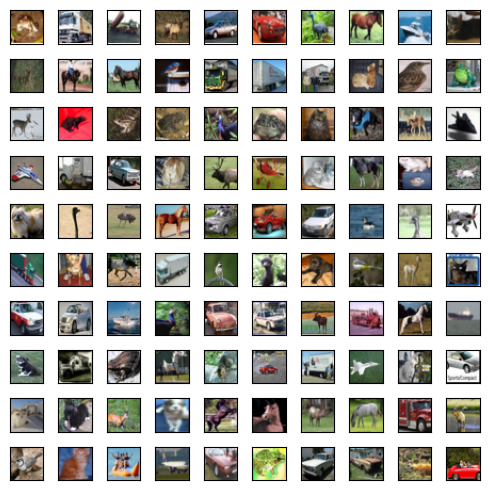

In [5]:
import numpy as np
import matplotlib.pyplot as plt

"""
for _, (data, _) in enumerate(loader):
    images = data[:3]
    break
for i in images:
    channel_last = np.transpose(i.numpy(), (1, 2, 0)) # (C, H, W) --> (H, W, C)
    plt.figure(figsize = (0.4,0.4))
    plt.imshow(channel_last)
    plt.show()
"""
num_row = 10
num_col = 10
fig, axes = plt.subplots(num_row, num_col, figsize=(5,5))
tmp_loader = torch.utils.data.DataLoader(dataset, batch_size=num_row*num_col, shuffle=False)
for data, _ in tmp_loader:
    for i in range(num_row*num_col):
        image = data[i].numpy()
        channel_last = np.transpose(image, (1, 2, 0)) # (C, H, W) --> (H, W, C)
        row = i//num_col
        col = i%num_col
        ax = axes[row, col]
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(channel_last)
    break
plt.tight_layout()
plt.show()
del tmp_loader

### 2. 构建 $\mathbf{s}_{\theta}$ (U-Net)

现在让我们为 SDE 构建得分函数（神经网络架构）$\mathbf{s}_{\theta}(\mathbf{x}, t)$。

在这个例子中，我们构建了论文 [[Song, et. al., 2021](https://arxiv.org/pdf/2011.13456)] 中使用的模型（DDPM++ cont.）。
这个架构主要基于 [DDPM 教程](./02-ddpm-cn.ipynb) 中的模型（来自 [[Ho et al., 2020](https://arxiv.org/pdf/2006.11239)]）。

首先我们构建时间嵌入。

与 [DDPM 教程](./02-ddpm-cn.ipynb) 相同，网络中的每个块也接收时间嵌入，但时间 $t \in [0, 1]$ 是连续的，因此我们不能应用在 [DDPM 教程](./02-ddpm-cn.ipynb) 中看到的常规位置嵌入（编码）。
因此，我们应用以下随机傅里叶特征嵌入，而不是应用位置嵌入。

In [7]:
import torch
import torch.nn as nn
from torch.nn import functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
#
# See https://arxiv.org/pdf/2006.10739
# (Gaussian version)
#
import math

class FourierFeatureEmbedding(nn.Module):
    def __init__(
        self,
        base_dim,   # 128
        scale=16.0, # 16  (see the paper in https://arxiv.org/pdf/2011.13456)
    ):
        super().__init__()

        # randomly sampled b
        # (no learnable parameters, but it must be saved !)
        self.b = nn.Parameter(
            torch.randn(base_dim) * scale,
            requires_grad=False
        )

    def forward(self, t):
        t_log = torch.log(t) # (apply as uniform-log variables)
        out = t_log[:, None] * self.b[None, :] # shape: [batch_size, base_dim]
        out = out * 2 * math.pi                # shape: [batch_size, base_dim]
        out = torch.cat([
            torch.sin(out),
            torch.cos(out)
        ], dim=-1)                             # shape: [batch_size, base_dim*2]
        return out

该模型基于 [DDPM 教程](./02-ddpm-cn.ipynb) 中的模型，但为了提高性能，它进行了修改。
以下是相对于原始 DDPM 的修改列表。

- 残差块（包括下采样和上采样）被替换为 BigGAN 架构 [[Brock et. al., 2018](https://arxiv.org/pdf/1809.11096)] 中的块。
  例如，下采样和上采样是通过平均池化实现的。（请参阅 [[Brock et. al., 2018](https://arxiv.org/pdf/1809.11096)] 中的附录 B。）
- 每个分辨率的残差块数量从 2 个增加到 4 个。
- 用 $\frac{1}{\sqrt{2}}$ 重新缩放残差连接。

![DDPM++ cont. 网络](./assets/sde_ddpmpp.png)

因此，以下源代码主要来自 [DDPM 教程](./02-ddpm-cn.ipynb)，但也应用了上述修改。

在官方实现中，它还包括基于 StyleGAN 架构中有限脉冲响应（简称 FIR）的渐进增长和抗锯齿的实现，但在本教程中没有应用这些架构。（更多细节，请参阅论文 [[Song, et. al., 2021](https://arxiv.org/pdf/2011.13456)] 中的附录 H.1。）

In [11]:
class ResnetBlock(nn.Module):
    def __init__(
        self,
        in_channel,
        out_channel,
        num_norm_groups, # 32
        time_embedding_dim, # 512
        updown=None, # specify "down" when downsampling and "up" when upsampling
    ):
        super().__init__()

        assert (updown is None) or (updown == "down") or (updown == "up")
        self.updown = updown

        # for normalization
        self.norm1 = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=in_channel,
            eps=1e-06,
        )
        self.norm2 = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=out_channel,
            eps=1e-06,
        )

        # for applying conv
        self.conv1 = nn.Conv2d(
            in_channel,
            out_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )
        self.conv2 = nn.Conv2d(
            out_channel,
            out_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )

        # for adding time condition
        self.linear_time = nn.Linear(time_embedding_dim, out_channel)

        # for residual block
        if (updown is not None) or (in_channel != out_channel):
            self.conv_src = nn.Conv2d(
                in_channel,
                out_channel,
                kernel_size=1,
                stride=1,
                padding=0,
            )
        else:
            self.conv_src = None

    def forward(self, x, t_emb):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            input x
        t_emb : torch.tensor((batch_size, base_channel_dim * 4), dtype=float)
            time embeddings
        """

        channel = x.size(dim=1)
        height = x.size(dim=2)
        width = x.size(dim=3)

        # apply group norm
        out = self.norm1(x)
        out = F.silu(out)

        # transform in each cases
        # (x_trans is used in last residual layer.)
        if self.updown == "down":
            out = F.avg_pool2d(out, (2, 2))
            x_trans = F.avg_pool2d(x, (2, 2))
        elif self.updown == "up":
            out = out[:,:,:,None,:,None]
            out = out.repeat(1, 1, 1, 2, 1, 2)
            out = torch.reshape(out, (-1, channel, height*2, width*2))
            x_trans = x[:,:,:,None,:,None]
            x_trans = x_trans.repeat(1, 1, 1, 2, 1, 2)
            x_trans = torch.reshape(x_trans, (-1, channel, height*2, width*2))
        else:
            x_trans = x

        # apply conv
        out = self.conv1(out)

        # adjust time embedding
        t_e = F.silu(t_emb)
        t_e = self.linear_time(t_e)
        t_e = t_e[:, :, None, None]
        out = out + t_e

        # apply dropout + conv
        out = self.norm2(out)
        out = F.silu(out)
        out = F.dropout(out, p=0.1, training=self.training)
        out = self.conv2(out)

        # apply residual
        if self.conv_src is not None:
            x_trans = self.conv_src(x_trans)
        out = out + x_trans

        # rescale
        out = out / math.sqrt(2.0)

        return out

#
# For the implementation of multi-head attention,
# see https://github.com/tsmatz/nlp-tutorials/blob/master/09_transformer.ipynb
#
class AttentionBlock(nn.Module):
    def __init__(
        self,
        channel,
        num_norm_groups, # 32
    ):
        super().__init__()

        self.norm = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=channel,
            eps=1e-06,
        )

        self.q_layer = nn.Linear(channel, channel)
        self.k_layer = nn.Linear(channel, channel)
        self.v_layer = nn.Linear(channel, channel)

        self.output_linear = nn.Linear(channel, channel, bias=False)

    def forward(self, x):
        channel = x.size(dim=1)
        height = x.size(dim=2)
        width = x.size(dim=3)

        out = self.norm(x)

        # reshape : (N,C,H,W) --> (N,H*W,C)
        out = out.permute(0, 2, 3, 1)
        out = out.view(-1, height*width, channel)

        # generate query/key/value
        q = self.q_layer(out)
        k = self.k_layer(out)
        v = self.v_layer(out)

        # compute Q K^T
        score = torch.einsum("bic,bjc->bij", q, k)

        # scale the result by 1/sqrt(channel)
        score = score / channel**0.5

        # apply softtmax
        score = F.softmax(score, dim=-1)

        # apply dot product with values
        out = torch.einsum("bij,bjc->bic", score, v)

        # apply final linear
        out = self.output_linear(out)

        # reshape : (N,H*W,C) --> (N,C,H,W)
        out = out.view(-1, height, width, channel)
        out = out.permute(0, 3, 1, 2)

        # apply residual
        out = out + x

        # rescale
        out = out / math.sqrt(2.0)

        return out

class ResnetAndAttention(nn.Module):
    def __init__(
        self,
        in_channel,
        out_channel,
        num_norm_groups, # 32
        time_embedding_dim, # 512
        updown=None, # specify "down" when downsampling and "up" when upsampling
    ):
        super().__init__()

        self.updown = updown

        self.resnet = ResnetBlock(
            in_channel,
            out_channel,
            num_norm_groups,
            time_embedding_dim,
            updown,
        )
        self.attention = AttentionBlock(
            out_channel,
            num_norm_groups,
        )

    def forward(self, x, t_emb):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            input x
        t_emb : torch.tensor((batch_size, base_channel_dim * 4), dtype=float)
            time embeddings
        """
        out = self.resnet(x, t_emb)
        out = self.attention(out)
        return out

In [13]:
class UNet(nn.Module):
    def __init__(
        self,
        source_channel, # 3
        unet_base_channel, # 128
        num_norm_groups, # 32
    ):
        super().__init__()

        ### for time embedding
        self.time_emb = FourierFeatureEmbedding(
            base_dim=unet_base_channel,
        )
        self.time_hidden = nn.Linear(
            unet_base_channel*2,
            unet_base_channel*4,
        )
        self.time_output = nn.Linear(
            unet_base_channel*4,
            unet_base_channel*4,
        )

        ### for unet main
        self.down_conv = nn.Conv2d(
            source_channel,
            unet_base_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )
        self.top_to_down = nn.ModuleList([
            # 1st layer
            ResnetBlock(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(    # downsampling
                in_channel=unet_base_channel,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
                updown="down",
            ),
            # 2nd layer
            ResnetAndAttention(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(    # downsampling
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
                updown="down",
            ),
            # 3rd layer
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(    # downsampling
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
                updown="down",
            ),
            # 4th layer
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
        ])
        self.middle = nn.ModuleList([
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            AttentionBlock(
                channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
        ])
        self.bottom_to_up = nn.ModuleList([
            # 1st layer
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(    # upsampling
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
                updown="up",
            ),
            # 2nd layer
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(    # upsampling
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
                updown="up",
            ),
            # 3rd layer
            ResnetAndAttention(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*3,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(    # upsampling
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
                updown="up",
            ),
            # 4th layer
            ResnetBlock(
                in_channel=unet_base_channel*3,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                time_embedding_dim=unet_base_channel*4,
            ),
        ])
        self.norm = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=unet_base_channel,
            eps=1e-06,
        )
        self.up_conv = nn.Conv2d(
            unet_base_channel,
            source_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )

    def forward(self, x, t):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            Gaussian-noised images
        t : torch.tensor((batch_size), dtype=float)
            time
        """

        buffer = []

        #
        # according to https://arxiv.org/pdf/1809.11096,
        # scale to zero-centered : [0, 1] to [-1, 1]
        #
        out = x * 2.0 - 1.0

        #
        # generate time embedding
        #
        time_embs = self.time_emb(t)
        time_embs = self.time_hidden(time_embs)
        time_embs = self.time_output(time_embs) # shape: [batch_size, unet_base_channel*4]

        #
        # Top-to-down
        #

        # apply down-convolution
        out = self.down_conv(out)
        buffer.append(out)
        # apply top-to-down
        for block in self.top_to_down:
            out = block(out, time_embs)
            buffer.append(out)

        #
        # Middle
        #
        for block in self.middle:
            if isinstance(block, ResnetBlock):
                out = block(out, time_embs)
            elif isinstance(block, AttentionBlock):
                out = block(out)
            else:
                raise Exception("Unknown block")

        #
        # Bottom-to-up
        #

        # apply bottom-to-up
        for block in self.bottom_to_up:
            if block.updown is None:
                buf = buffer.pop()
                out = torch.cat((out, buf), dim=1)
            out = block(out, time_embs)
        # apply up-convolution
        out = self.norm(out)
        out = F.silu(out)
        out = self.up_conv(out)

        #
        # back to original scaling: [-1, 1] to [0, 1]
        #
        out = out / 2.0 + 0.5

        assert not buffer

        return out

In [15]:
#
# Generate model
#
unet = UNet(
    source_channel=3,
    unet_base_channel=128,
    num_norm_groups=32,
).to(device)

### 3. 训练（优化）$\mathbf{s}_{\theta}$

现在让我们训练 $\mathbf{s}_{\theta}$。

正如我们在方程 (7) 中所见，我们应该优化 $\theta$ 以最小化以下损失：

$\displaystyle \theta^{\ast} = \arg \min_{\theta} \left\{ \mathbb{E}\left[ \left\|\sigma(t)\mathbf{s}_{\theta}(\tilde{\mathbf{x}}, t) + \mathbf{z} \right\|^2 \right] \right\} \;\;\;\;\;\; (7)$

其中

- $\sigma(t)^2 = 1 - e^{-\frac{1}{2}t^2(\bar{\beta}_{\max} - \bar{\beta}_{\min})-t\bar{\beta}_{\min}}$
- $\tilde{\mathbf{x}} = e^{-\frac{1}{4}t^2(\bar{\beta}_{\max} - \bar{\beta}_{\min})-\frac{1}{2}t\bar{\beta}_{\min}} \mathbf{x}(0) + \sigma(t) \mathbf{z}$ &nbsp;&nbsp;&nbsp;&nbsp; (其中 $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}))$

在这个例子中，我们假设 $N=1000$，即 $\Delta t = 1 / 1000$。（$N$ 在训练中没有使用，但在推理中会用到。）
正如我们在 [DDPM 教程](./02-ddpm-cn.ipynb) 中所见，$\beta_{\min}=10^{-4}$ 和 $\beta_{\max}=0.02$ 提供了更好的性能，因此我配置了 $\bar{\beta}_{\min} = 10^{-4} / \Delta t = 0.1$ 和 $\bar{\beta}_{\max} = 0.02 / \Delta t = 20$。

对于时间 t，我们在每个步骤中选取随机的 $t \in [0,1]$。然而，在实际训练中，当 $t \to 0$ 时，方程 (6) 中会出现方差消失。
因此，我们选取 $t \in [\epsilon,1]$，其中 $\epsilon$ 是通过实验确定的，论文称 $\epsilon=10^{-5}$ 将在训练中提供更好的性能。

（有关参数设置，请参阅原始论文 [[Song, et. al., 2021](https://arxiv.org/pdf/2011.13456)] 中的附录 C。）

> **Note：** 本次实验在训练 600 个 epoch 后停止，但如需获得更高质量的生成样本，请继续进行更长时间的训练。  
> 在单张 GPU 上完成完整训练通常需要数天时间。

> 注：论文 [[Song, et. al., 2021](https://arxiv.org/pdf/2011.13456)] 称指数移动平均（EMA）对模型性能有显著影响。（EMA 也应用于 [官方仓库](https://github.com/yang-song/score_sde) 的实现中。）
> 为了简化我们的代码，本示例中没有应用 EMA。（在生产中请应用 EMA。）

In [20]:
import os

# initialize optimizer
opt = torch.optim.Adam(unet.parameters(), lr=2e-4)

# remove log file if exists
log_file = "train_loss.log"
if os.path.exists(log_file):
    os.remove(log_file)

# initialize parameters (see above)
beta_min = 0.1
beta_max = 20.0
eps = 1e-5

# loop
num_epochs = 500
for epoch_idx in range(num_epochs):
    epoch_loss = []
    for batch_idx, (data, _) in enumerate(loader):
        unet.train()
        opt.zero_grad()

        # pick up x
        x_0 = data.to(device)

        # generate time t (see above for epsilon)
        b = x_0.size(dim=0)
        t = torch.rand(b).to(device) * (1.0 - eps) + eps  # shape (batch_size)

        # get mean and standard deviation in \tilde{x}
        # (see equation (6))
        mean_x = torch.exp(-0.25 * t**2 * (beta_max - beta_min) - 0.5 * t * beta_min)  # shape (batch_size)
        std_x = torch.sqrt(1.0 - torch.exp(-0.5 * t**2 * (beta_max - beta_min) - t * beta_min))  # shape (batch_size)

        # get \tilde{x}
        z = torch.randn_like(x_0).to(device)
        x = mean_x[:, None, None, None] * x_0 + std_x[:, None, None, None] * z

        # get model output (score function's output)
        model_out = unet(x, t)

        # get loss
        loss = torch.square(std_x[:, None, None, None] * model_out + z)
        loss = torch.mean(loss, dim=(1,2,3))
        loss = torch.mean(loss)

        # optimize
        loss.backward()
        opt.step()

        # log
        epoch_loss.append(loss.item())
        print("epoch{} (iter{}) - loss {:5.4f}".format(epoch_idx+1, batch_idx+1, loss), end="\r")

    # finalize epoch (save log and checkpoint)
    epoch_average_loss = sum(epoch_loss)/len(epoch_loss)
    print("epoch{} (iter{}) - loss {:5.4f}".format(epoch_idx+1, batch_idx+1, epoch_average_loss))
    with open(log_file, "a") as f:
        for l in epoch_loss:
            f.write("%s\n" %l)
    torch.save(unet.state_dict(), f"sde_ddpmpp_{epoch_idx}.pt")

print("Done")

epoch1 (iter391) - loss 0.1181
epoch2 (iter391) - loss 0.0540
epoch3 (iter391) - loss 0.0422
epoch4 (iter391) - loss 0.0371
epoch5 (iter391) - loss 0.0330
epoch6 (iter391) - loss 0.0540
epoch7 (iter391) - loss 0.0394
epoch8 (iter391) - loss 0.0342
epoch9 (iter391) - loss 0.0326
epoch10 (iter391) - loss 0.0310
epoch11 (iter391) - loss 0.0306
epoch12 (iter391) - loss 0.0286
epoch13 (iter391) - loss 0.0275
epoch14 (iter391) - loss 0.0269
epoch15 (iter391) - loss 0.0271
epoch16 (iter391) - loss 0.0248
epoch17 (iter391) - loss 0.0250
epoch18 (iter391) - loss 0.0246
epoch19 (iter391) - loss 0.0246
epoch20 (iter391) - loss 0.0242
epoch22 (iter391) - loss 0.0232
epoch23 (iter391) - loss 0.0222
epoch24 (iter391) - loss 0.0229
epoch25 (iter391) - loss 0.0228
epoch26 (iter391) - loss 0.0218
epoch27 (iter391) - loss 0.0224
epoch28 (iter391) - loss 0.0216


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



epoch67 (iter391) - loss 0.0186
epoch68 (iter391) - loss 0.0189
epoch69 (iter391) - loss 0.0187
epoch70 (iter391) - loss 0.0187
epoch71 (iter391) - loss 0.0185
epoch72 (iter391) - loss 0.0186
epoch73 (iter391) - loss 0.0184
epoch74 (iter391) - loss 0.0182
epoch75 (iter391) - loss 0.0184
epoch76 (iter391) - loss 0.0184
epoch77 (iter391) - loss 0.0181
epoch78 (iter391) - loss 0.0188
epoch79 (iter391) - loss 0.0182
epoch80 (iter391) - loss 0.0184
epoch81 (iter391) - loss 0.0183
epoch82 (iter391) - loss 0.0182
epoch83 (iter391) - loss 0.0184
epoch84 (iter391) - loss 0.0187
epoch85 (iter391) - loss 0.0184
epoch86 (iter391) - loss 0.0185
epoch87 (iter391) - loss 0.0183
epoch89 (iter391) - loss 0.0184
epoch90 (iter391) - loss 0.0180
epoch91 (iter391) - loss 0.0179
epoch92 (iter391) - loss 0.0182
epoch93 (iter391) - loss 0.0181
epoch94 (iter391) - loss 0.0178
epoch95 (iter391) - loss 0.0181


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



epoch474 (iter391) - loss 0.0169
epoch475 (iter391) - loss 0.0168
epoch476 (iter391) - loss 0.0171
epoch477 (iter391) - loss 0.0167
epoch478 (iter391) - loss 0.0172
epoch479 (iter391) - loss 0.0167


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



epoch492 (iter391) - loss 0.0165
epoch493 (iter391) - loss 0.0167
epoch494 (iter391) - loss 0.0166
epoch495 (iter391) - loss 0.0168
epoch496 (iter391) - loss 0.0167
epoch497 (iter391) - loss 0.0169
epoch498 (iter391) - loss 0.0167
epoch499 (iter391) - loss 0.0165
epoch500 (iter391) - loss 0.0167
Done


显示训练中前 10 个 epoch 的损失变化。

## 使用训练好的模型生成图像

现在让我们使用上述训练好的模型创建图像。

正如我上面提到的，我们可以通过以下方式获得下一个样本：

$\displaystyle \mathbf{x}_i = \mathbf{x}_{i+1} + \frac{\beta(t)}{N} \left[\frac{1}{2}\mathbf{x}_{i+1} + \mathbf{s}_{\theta^{\ast}}(\mathbf{x}_{i+1}, t_{i+1})\right] + \sqrt{\frac{\beta(t)}{N}} \mathbf{z} $

其中 $\theta^{\ast}$ 是训练好的参数，$\mathbf{z} \sim \mathcal{N}(\mathbf{0},\mathbf{I})$。

在这个方程中，$\beta(t)$ 由以下方式获得：$\bar{\beta}_{\min} + t(\bar{\beta}_{\max} - \bar{\beta}_{\min})$。

论文称 $\epsilon=10^{-3}$ 将在推理中提供更好的性能，因此我设置了 `eps=0.001`。

100%|██████████| 1000/1000 [01:52<00:00,  8.92it/s]


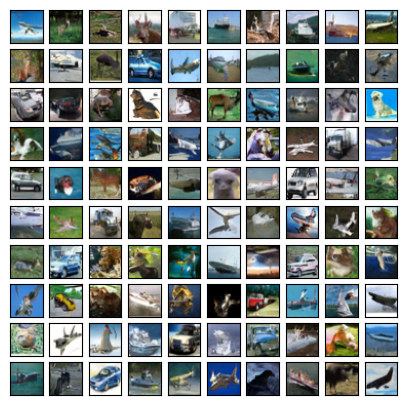

In [20]:
import tqdm

N = 1000

def run_inference(unet, x_0, beta_min, beta_max, eps, N):
    unet.eval()

    t_steps = torch.linspace(1.0, 0.0, N).to(device) * (1.0 - eps) + eps
    x = x_0
    b = x_0.size(dim=0)
    with torch.no_grad():
        # (showing progress, because it needs a lot of time.)
        for i, t in tqdm.tqdm(enumerate(t_steps), total=N):
            model_out = unet(x, t.repeat(b))
            beta_t = beta_min + (beta_max - beta_min) * t
            z = torch.randn_like(x).to(device)
            if i == N - 1:
                x = x + (beta_t / N) * (0.5 * x + model_out)
            else:
                x = x + (beta_t / N) * (0.5 * x + model_out) + torch.sqrt(beta_t / N) * z

    # clip
    x = torch.clamp(x, min=0.0, max=1.0)
    return x

num_row = 10
num_col = 10

# initialize x_0
x_0 = torch.randn(num_row * num_col, 3, 32, 32).to(device)
# generate images
x = run_inference(unet, x_0, beta_min, beta_max, eps=0.001, N=N)
# draw
fig, axes = plt.subplots(num_row, num_col, figsize=(5,5))
for i in range(num_row*num_col):
    image = x[i].cpu().numpy()
    channel_last = np.transpose(image, (1, 2, 0)) # (C, H, W) --> (H, W, C)
    row = i//num_col
    col = i%num_col
    ax = axes[row, col]
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(channel_last)

### 使用 Predictor–Corrector (PC) 采样框架进行图像生成

在 **Predictor–Corrector (PC)** 框架中，反向生成过程被拆分为两个在时间维度上交替执行的步骤：**预测器（Predictor）** 与 **校正器（Corrector）**。二者共同作用，用于稳定、高质量地近似反向 SDE 的采样过程。

> 注意：在 Predictor 和 Langevin Corrector 中使用同一个 UNet, 因为模型表示的是时刻 𝑡 下数据分布的 score 函数

#### 预测器（Predictor）

预测器采用 **Euler–Maruyama** 方法，对反向时间 SDE 进行一步数值积分。  
在代码中，这一过程发生在离散时间步 $t_i \rightarrow t_{i-1}$ 上，其核心作用是：

- 根据当前样本 $\mathbf{x}_t$
- 以及模型输出的 score 函数 $\mathbf{s}_\theta(\mathbf{x}_t, t)$
- 同时考虑确定性漂移项与随机扩散项

得到下一个时间步的预测样本 $\mathbf{x}_{t-\Delta t}$。

这一阶段决定了样本沿着反向扩散轨迹的大方向演化，是生成过程的“主干路径”。

#### 校正器（Corrector）

在完成一次 Predictor 更新后，PC 框架并不会立刻进入下一个时间步，而是在**固定时间 $t$** 下插入一个校正过程，即 **Langevin MCMC** 采样。

校正器的核心更新规则为：

$$
\mathbf{x} \leftarrow \mathbf{x}
\;+\;
\text{snr} \cdot \sigma(t)^2 \cdot \mathbf{s}_\theta(\mathbf{x}, t)
\;+\;
\sqrt{2\,\text{snr}} \cdot \sigma(t) \cdot \mathbf{z},
\qquad \mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})
$$

> Corrector 中对 score 乘以 $\sigma_t^2$，是为了消除 score 自身的时间尺度偏置，使 Langevin MCMC 在所有噪声水平下都能以正确尺度采样 $p_t(x)$，这是保证 Predictor 与 Corrector 在同一 SDE 物理系统下协同工作的必要条件

100%|██████████| 1000/1000 [56:49<00:00,  3.41s/it]


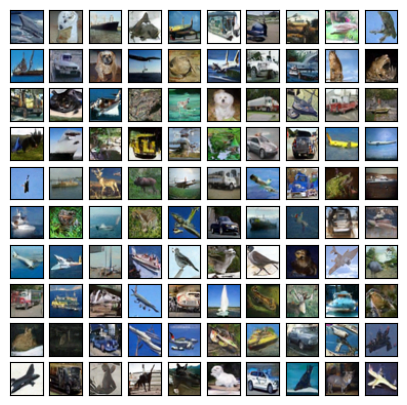

In [39]:
import tqdm

N = 1000

def langevin_corrector(
    x,
    unet,
    t,
    beta_min,
    beta_max,
    snr=1e-3,
    n_steps=1
):
    """
    Langevin Corrector aligned with VP-SDE training

    Update rule:
    x <- x + snr * sigma(t)^2 * score + sqrt(2*snr) * sigma(t) * z
    """
    b = x.size(0)

    # sigma(t) from training
    sigma = torch.sqrt(
        1.0 - torch.exp(
            -0.5 * t**2 * (beta_max - beta_min)
            - t * beta_min
        )
    )

    for _ in range(n_steps):
        # score s_theta(x, t)
        score = unet(x, t.repeat(b))

        # Gaussian noise
        z = torch.randn_like(x)

        # Langevin update
        x = (
            x
            + snr * (sigma ** 2) * score
            + torch.sqrt(torch.tensor(2.0 * snr, device=x.device)) * sigma * z
        )

    return x


def run_inference_pc(unet, x_0, beta_min, beta_max, eps, N, snr, corrector_steps=1):
    """
    Predictor-Corrector sampler.
    Predictor: Euler–Maruyama
    Corrector: Langevin MCMC
    """
    unet.eval()

    t_steps = torch.linspace(1.0, 0.0, N).to(device) * (1.0 - eps) + eps
    x = x_0
    b = x_0.size(0)

    with torch.no_grad():
        for i, t in tqdm.tqdm(enumerate(t_steps), total=N):

            # ---------- Predictor (Euler–Maruyama) ----------
            model_out = unet(x, t.repeat(b))
            beta_t = beta_min + (beta_max - beta_min) * t
            z = torch.randn_like(x)

            if i == N - 1:
                # final step (no noise)
                x = x + (beta_t / N) * (0.5 * x + model_out)
            else:
                x = x + (beta_t / N) * (0.5 * x + model_out) + torch.sqrt(beta_t / N) * z

            # ---------- Corrector (Langevin MCMC) ----------
            x = langevin_corrector(
                x, unet, t,
                beta_min, beta_max,
                snr=snr,
                n_steps=corrector_steps
            )

    # clip to image range
    x = torch.clamp(x, 0.0, 1.0)
    return x

# -------------------------------------------------------
# 使用 PC 框架生成图像
# -------------------------------------------------------

num_row = 10
num_col = 10

x_0 = torch.randn(num_row * num_col, 3, 32, 32).to(device)

x = run_inference_pc(
    unet,
    x_0,
    beta_min, beta_max,
    eps=0.001,
    N=N,
    snr=1e-3,         # Langevin noise scale
    corrector_steps=10    # 每步 1 次 corrector
)


# draw
fig, axes = plt.subplots(num_row, num_col, figsize=(5,5))
for i in range(num_row*num_col):
    image = x[i].cpu().numpy()
    channel_last = np.transpose(image, (1, 2, 0)) # (C, H, W) --> (H, W, C)
    row = i//num_col
    col = i%num_col
    ax = axes[row, col]
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(channel_last)